In [3]:
# local imports
from config import Config
from Emotion_model.Emotion import with_LLm, get_emotion_sentiment_intensity_tone

# standard library
import os
from dotenv import load_dotenv
from typing import TypedDict,Annotated,List,Literal
from pydantic import BaseModel,Field

# langgraph
from langgraph.graph import StateGraph,START,END

# langchain
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage

from dotenv import load_dotenv

c:\Users\LENOVO\OneDrive\Desktop\Ai agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 105/105 [00:00<?, ?it/s]
c:\Users\LENOVO\OneDrive\Desktop\Ai agent\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
llm_model = ChatGroq(
    model='openai/gpt-oss-20b'
)

In [5]:
class emotion_sentiment_intensity_tone(TypedDict):
    emotion: str
    sentiment: str
    intensity: float
    tone: str

In [6]:
class prenetState(TypedDict):
    user_message: str
    user_emotion_sentiment_intensity_tone: emotion_sentiment_intensity_tone
    response: str
    

In [7]:
graph = StateGraph(prenetState)

In [8]:
def detect_emotion(state: prenetState):
    # emotion = get_emotion_sentiment_intensity_tone(state['user_message'])
    emotion = with_LLm.get_emotion_sentiment_intensity_tone_with_LLM(state['user_message'])
    return {'user_emotion_sentiment_intensity_tone': emotion}

def chake_condition(state:prenetState) -> Literal['agent_responce','tools_call']:
    if state['user_emotion_sentiment_intensity_tone']['tone']['is_task'] == True:
        return tools_call
    else:
        return agent_responce


def agent_responce(state:prenetState):
    respoince = llm_model.invoke([
        SystemMessage(content="You are a helpful assistant that responds to the user based on their emotion, sentiment, intensity, and tone."),
        HumanMessage(content=f""""User message: {state['user_message']}\nEmotion: {state['user_emotion_sentiment_intensity_tone']['emotion']}\n
        Sentiment: {state['user_emotion_sentiment_intensity_tone']['sentiment']}\nIntensity: {state['user_emotion_sentiment_intensity_tone']['intensity']}\n
        Tone: {state['user_emotion_sentiment_intensity_tone']['tone']}\nPlease provide a response to the user based on their emotional state."""),
        ]).content
    return {'agent_response': respoince}

def tool_call(state:prenetState):
    pass
    

In [9]:
graph.add_node('detect_emotion', detect_emotion)
graph.add_node('agent_responce',agent_responce)
graph.add_node('tools_call',tool_call)

graph.add_edge(START,'detect_emotion')
graph.add_conditional_edges('detect_emotion', chake_condition)
graph.add_edge('agent_responce', END)
graph.add_edge('tools_call', END)

agent = graph.compile()

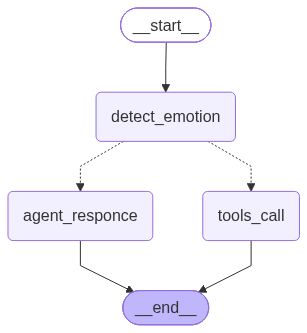

In [10]:
agent

AttributeError: 'StateGraph' object has no attribute 'add'